<a href="https://colab.research.google.com/github/challistarisk/pengolahancitra/blob/main/Jobsheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1: Transformasi Kurva (Citra Negatif

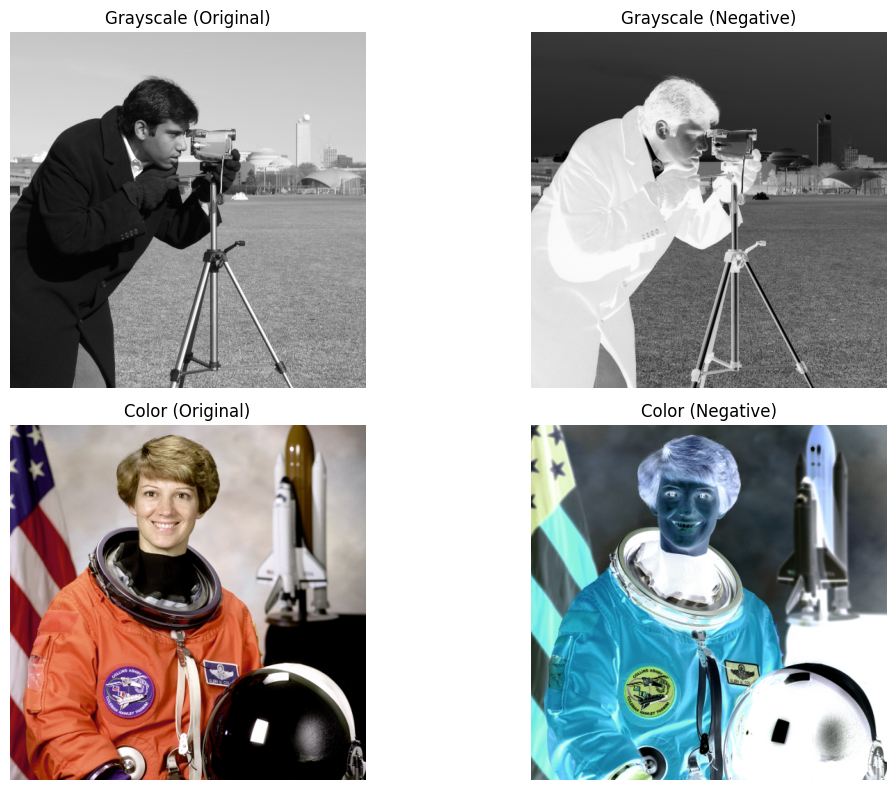

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# Grayscale Negative
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)
negative_gray = 1.0 - image_gray_float

# Color Negative
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)
negative_color = 1.0 - image_color_float

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


Praktikum 2: Histogram dan Ekualisasi Histogram

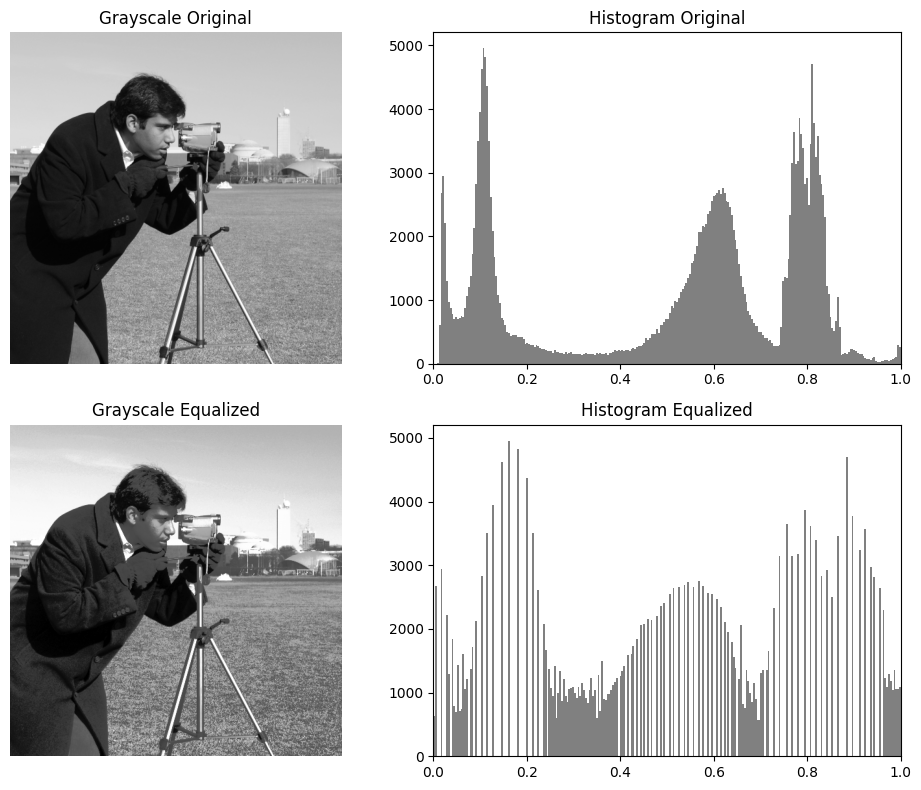

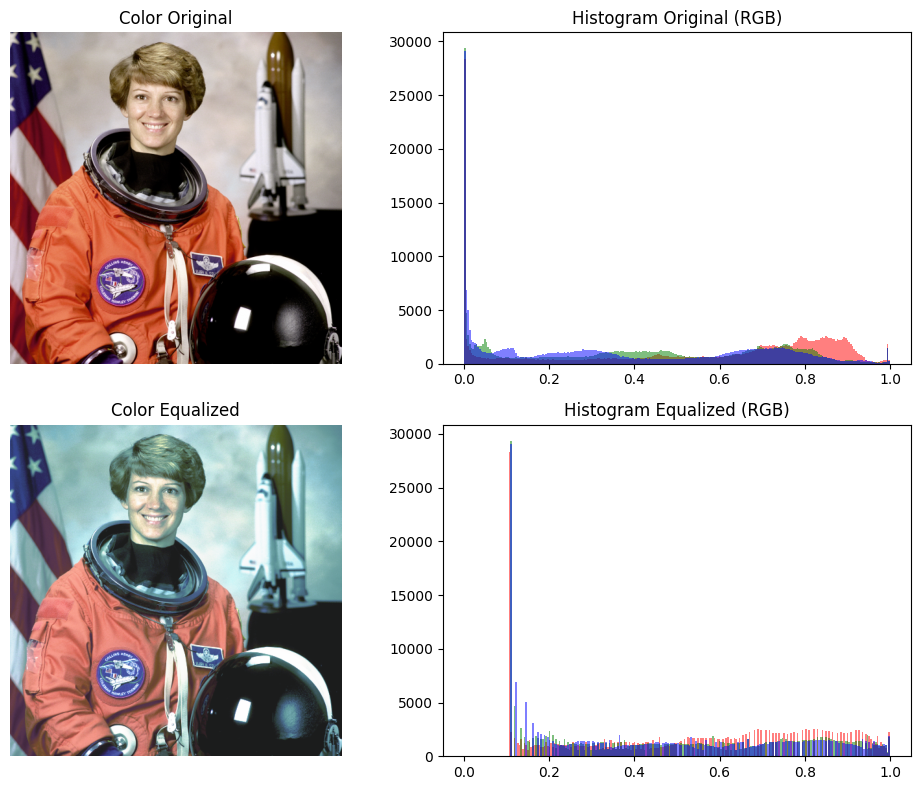

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# Grayscale Histogram
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)
image_gray_eq = exposure.equalize_hist(image_gray)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Color Histogram
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)
r, g, b = image_color[:,:,0], image_color[:,:,1], image_color[:,:,2]
r_eq = exposure.equalize_hist(r)
g_eq = exposure.equalize_hist(g)
b_eq = exposure.equalize_hist(b)
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r.ravel(), bins=256, range=(0,1), color='red', alpha=0.5)
axes2[0, 1].hist(g.ravel(), bins=256, range=(0,1), color='green', alpha=0.5)
axes2[0, 1].hist(b.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5)
axes2[0, 1].set_title("Histogram Original (RGB)")

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5)
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5)
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5)
axes2[1, 1].set_title("Histogram Equalized (RGB)")

plt.tight_layout()
plt.show()


Praktikum 3: Konvolusi (Filter Rata-rata)

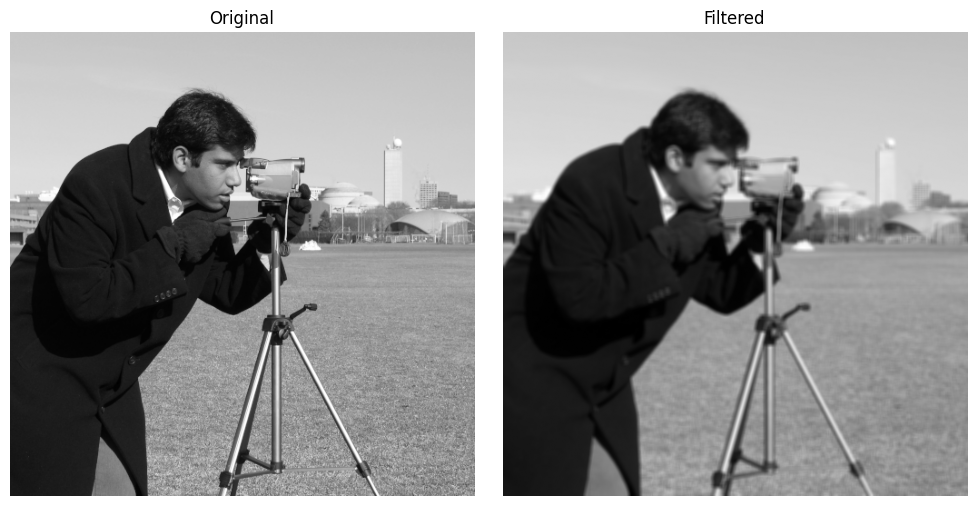

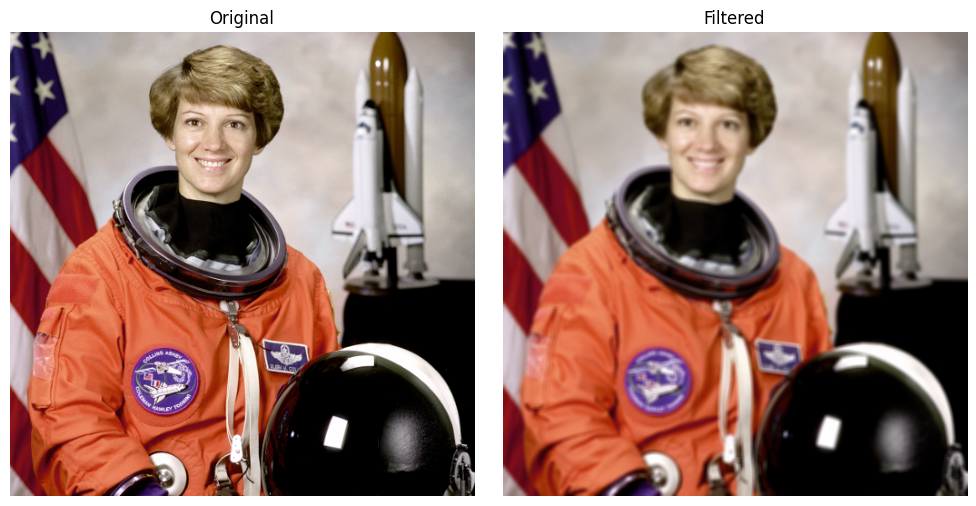

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# Grayscale
gray_img = img_as_float(data.camera())
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title("Filtered")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# RGB
color_img = img_as_float(data.astronaut())
color_filtered = np.zeros_like(color_img)
for c in range(3):
    color_filtered[:, :, c] = ndi.convolve(color_img[:, :, c], kernel, mode='reflect')

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Original")
axes2[0].axis('off')
axes2[1].imshow(color_filtered)
axes2[1].set_title("Filtered")
axes2[1].axis('off')
plt.tight_layout()
plt.show()


 Praktikum 4: Filter Median (Penghilangan Derau)

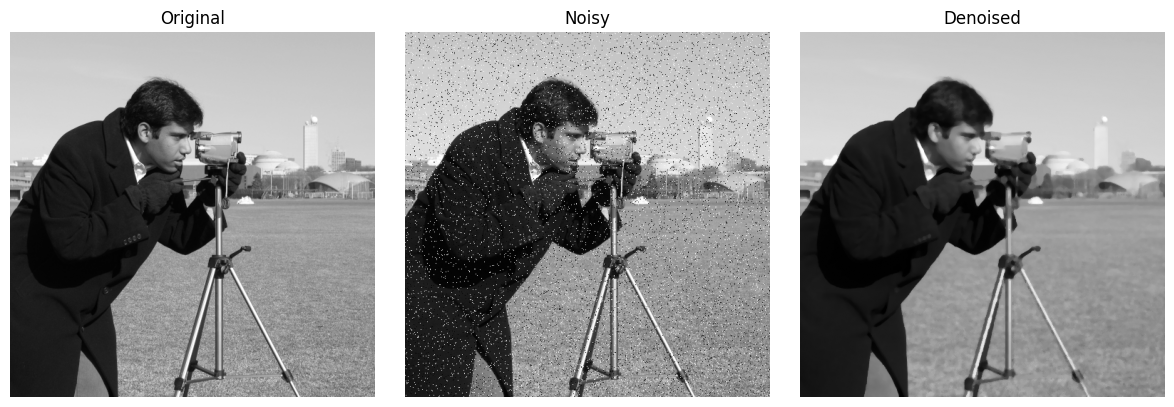

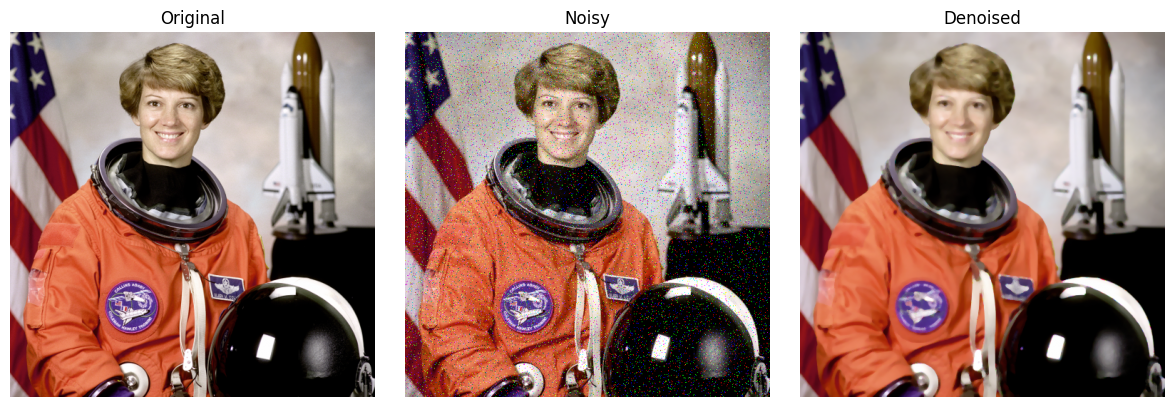

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# Grayscale + Salt & Pepper
gray_img = img_as_float(data.camera())
gray_noisy = util.random_noise(gray_img, mode='s&p', amount=0.05)
gray_denoised = filters.median(gray_noisy, morphology.disk(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Noisy")
axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Denoised")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# RGB + Salt & Pepper
color_img = img_as_float(data.astronaut())
color_noisy = util.random_noise(color_img, mode='s&p', amount=0.05)
color_denoised = np.zeros_like(color_noisy)
for c in range(3):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_img)
axes2[0].set_title("Original")
axes2[1].imshow(color_noisy)
axes2[1].set_title("Noisy")
axes2[2].imshow(color_denoised)
axes2[2].set_title("Denoised")
for ax in axes2: ax.axis('off')
plt.tight_layout()
plt.show()
